In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


In [7]:
data_path = "../data/raw/"
all_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]

df_list = []
for file in all_files:
    temp = pd.read_csv(os.path.join(data_path, file), encoding='utf-8', low_memory=False)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
df.columns = df.columns.str.strip()
print(f"✅ Dataset loaded: {df.shape}")

✅ Dataset loaded: (2830743, 79)


In [8]:
# Fix broken characters in label names (the â€¦ you saw)
df['Label'] = df['Label'].str.strip()

label_fix = {
    'Web Attack \x96 Brute Force'  : 'Web Attack - Brute Force',
    'Web Attack \x96 XSS'          : 'Web Attack - XSS',
    'Web Attack \x96 Sql Injection' : 'Web Attack - Sql Injection',
    'Web Attack â\x80\x93 Brute Force'  : 'Web Attack - Brute Force',
    'Web Attack â\x80\x93 XSS'          : 'Web Attack - XSS',
    'Web Attack â\x80\x93 Sql Injection' : 'Web Attack - Sql Injection',
}
df['Label'] = df['Label'].replace(label_fix)

print("=== Cleaned Labels ===")
print(df['Label'].value_counts())

=== Cleaned Labels ===
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [9]:
# These columns don't help the model
cols_to_drop = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp',
                'Source Port', 'Destination Port', 'source_file']

# Only drop columns that actually exist
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f"✅ Dropped: {cols_to_drop}")
print(f"Remaining columns: {df.shape[1]}")

✅ Dropped: ['Destination Port']
Remaining columns: 78


In [10]:
# Replace inf with NaN then fill
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN with column median (robust to outliers)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Drop duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)

print(f"✅ Inf/NaN fixed")
print(f"✅ Duplicates removed: {before - after:,} rows dropped")
print(f"Final shape: {df.shape}")

✅ Inf/NaN fixed
✅ Duplicates removed: 596,780 rows dropped
Final shape: (2233963, 78)


In [11]:
# --- Multi-class label (15 categories) ---
ATTACK_TYPES = [
    'BENIGN', 'DoS Hulk', 'PortScan', 'DDoS', 'DoS GoldenEye',
    'FTP-Patator', 'SSH-Patator', 'DoS slowloris', 'DoS Slowhttptest',
    'Bot', 'Web Attack - Brute Force', 'Web Attack - XSS',
    'Infiltration', 'Web Attack - Sql Injection', 'Heartbleed'
]

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Label'])

# Save label encoder
os.makedirs('../models/saved', exist_ok=True)
joblib.dump(le, '../models/saved/label_encoder.pkl')

print("=== Multi-class label mapping ===")
for i, cls in enumerate(le.classes_):
    print(f"  {i:2d} → {cls}")

# --- Binary label: 0 = BENIGN, 1 = ATTACK ---
df['binary_label'] = (df['Label'] != 'BENIGN').astype(int)

print(f"\n✅ Binary label: 0=BENIGN ({(df['binary_label']==0).sum():,})  |  1=ATTACK ({(df['binary_label']==1).sum():,})")

=== Multi-class label mapping ===
   0 → BENIGN
   1 → Bot
   2 → DDoS
   3 → DoS GoldenEye
   4 → DoS Hulk
   5 → DoS Slowhttptest
   6 → DoS slowloris
   7 → FTP-Patator
   8 → Heartbleed
   9 → Infiltration
  10 → PortScan
  11 → SSH-Patator
  12 → Web Attack � Brute Force
  13 → Web Attack � Sql Injection
  14 → Web Attack � XSS

✅ Binary label: 0=BENIGN (1,897,458)  |  1=ATTACK (336,505)


In [12]:
X = df.drop(columns=['Label', 'label_encoded', 'binary_label'])
y_binary = df['binary_label']
y_multi  = df['label_encoded']

print(f"Features (X) shape : {X.shape}")
print(f"Binary target      : {y_binary.shape}")
print(f"Multi-class target : {y_multi.shape}")

Features (X) shape : (2233963, 77)
Binary target      : (2233963,)
Multi-class target : (2233963,)


In [13]:
print("Running feature selection (this may take 1-2 min)...")

selector = SelectKBest(score_func=f_classif, k=40)
selector.fit(X, y_binary)

selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()

print(f"\n✅ Top 40 selected features:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")

# Save feature list
joblib.dump(selected_features, '../models/saved/selected_features.pkl')
print("\n✅ Saved to models/saved/selected_features.pkl")

Running feature selection (this may take 1-2 min)...

✅ Top 40 selected features:
   1. Flow Duration
   2. Fwd Packet Length Min
   3. Fwd Packet Length Mean
   4. Bwd Packet Length Max
   5. Bwd Packet Length Min
   6. Bwd Packet Length Mean
   7. Bwd Packet Length Std
   8. Flow Packets/s
   9. Flow IAT Mean
  10. Flow IAT Std
  11. Flow IAT Max
  12. Fwd IAT Total
  13. Fwd IAT Mean
  14. Fwd IAT Std
  15. Fwd IAT Max
  16. Bwd IAT Std
  17. Bwd IAT Max
  18. Fwd PSH Flags
  19. Fwd Packets/s
  20. Bwd Packets/s
  21. Min Packet Length
  22. Max Packet Length
  23. Packet Length Mean
  24. Packet Length Std
  25. Packet Length Variance
  26. FIN Flag Count
  27. SYN Flag Count
  28. ACK Flag Count
  29. URG Flag Count
  30. Down/Up Ratio
  31. Average Packet Size
  32. Avg Fwd Segment Size
  33. Avg Bwd Segment Size
  34. Init_Win_bytes_forward
  35. Init_Win_bytes_backward
  36. Active Min
  37. Idle Mean
  38. Idle Std
  39. Idle Max
  40. Idle Min

✅ Saved to models/saved/select

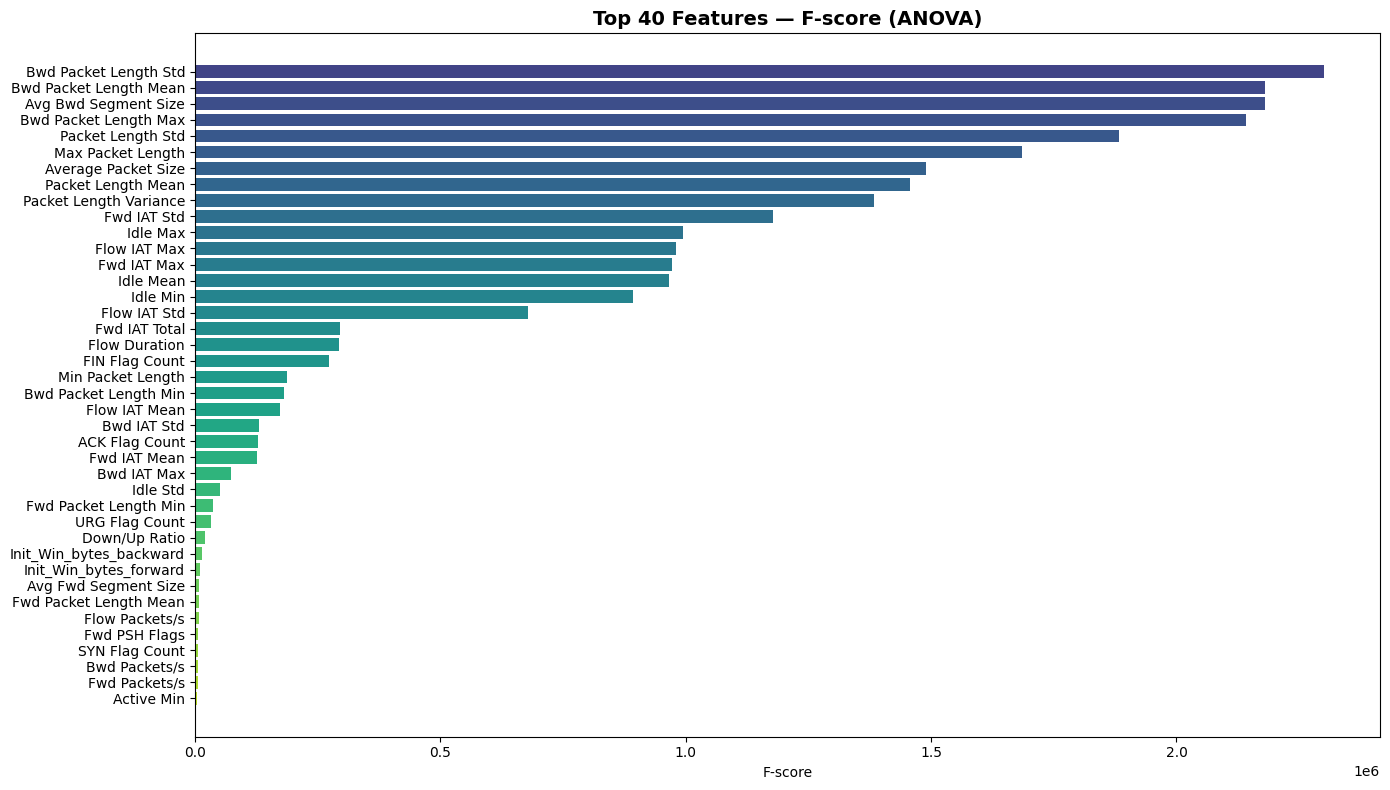

✅ Saved to reports/feature_importance.png


In [14]:
scores = selector.scores_[selected_mask]
feat_scores = pd.Series(scores, index=selected_features).sort_values(ascending=False)

plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_scores)))
plt.barh(feat_scores.index[::-1], feat_scores.values[::-1], color=colors[::-1])
plt.title("Top 40 Features — F-score (ANOVA)", fontsize=14, fontweight='bold')
plt.xlabel("F-score")
plt.tight_layout()
plt.savefig("../reports/feature_importance.png", dpi=150)
plt.show()
print("✅ Saved to reports/feature_importance.png")

In [15]:
X = X[selected_features]
print(f"✅ X reduced to top 40 features: {X.shape}")

✅ X reduced to top 40 features: (2233963, 40)


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=selected_features)

joblib.dump(scaler, '../models/saved/scaler.pkl')
print("✅ StandardScaler fitted and saved")
print(f"X_scaled shape: {X_scaled.shape}")

✅ StandardScaler fitted and saved
X_scaled shape: (2233963, 40)


In [17]:
print("Applying SMOTE to balance binary classes...")
print(f"Before SMOTE: {y_binary.value_counts().to_dict()}")

# Use SMOTE + undersampling combo to avoid memory issues
over  = SMOTE(sampling_strategy=0.3, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.6, random_state=42)

pipeline = ImbPipeline([('over', over), ('under', under)])
X_resampled, y_resampled = pipeline.fit_resample(X_scaled, y_binary)

print(f"After  SMOTE: {pd.Series(y_resampled).value_counts().to_dict()}")
print(f"Resampled shape: {X_resampled.shape}")

Applying SMOTE to balance binary classes...
Before SMOTE: {0: 1897458, 1: 336505}
After  SMOTE: {0: 948728, 1: 569237}
Resampled shape: (1517965, 40)


In [18]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
print("✅ Fixed")

✅ Fixed


In [19]:
# Split resampled data for binary classification
X_train, X_temp, y_train, y_temp = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("=== Binary classification splits ===")
print(f"  Train : {X_train.shape}  |  Attack%: {y_train.mean()*100:.1f}%")
print(f"  Val   : {X_val.shape}   |  Attack%: {y_val.mean()*100:.1f}%")
print(f"  Test  : {X_test.shape}   |  Attack%: {y_test.mean()*100:.1f}%")

# Also make a multi-class split from original (not SMOTE'd) data
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_scaled, y_multi, test_size=0.2, random_state=42, stratify=y_multi)

print(f"\n=== Multi-class splits ===")
print(f"  Train : {X_tr_m.shape}")
print(f"  Test  : {X_te_m.shape}")

=== Binary classification splits ===
  Train : (1062575, 40)  |  Attack%: 37.5%
  Val   : (227695, 40)   |  Attack%: 37.5%
  Test  : (227695, 40)   |  Attack%: 37.5%

=== Multi-class splits ===
  Train : (1787170, 40)
  Test  : (446793, 40)


In [20]:
save_path = "../data/processed/"
os.makedirs(save_path, exist_ok=True)

# Binary splits
np.save(save_path + "X_train.npy", X_train)
np.save(save_path + "X_val.npy",   X_val)
np.save(save_path + "X_test.npy",  X_test)
np.save(save_path + "y_train.npy", y_train)
np.save(save_path + "y_val.npy",   y_val)
np.save(save_path + "y_test.npy",  y_test)

# Multi-class splits
np.save(save_path + "X_train_multi.npy", X_tr_m)
np.save(save_path + "X_test_multi.npy",  X_te_m)
np.save(save_path + "y_train_multi.npy", y_tr_m)
np.save(save_path + "y_test_multi.npy",  y_te_m)

# Also save scaled full dataframe for autoencoder (Step 5)
X_scaled.to_csv(save_path + "X_full_scaled.csv", index=False)
pd.Series(y_binary).to_csv(save_path + "y_binary_full.csv", index=False)

print("✅ All splits saved to data/processed/")
print("\nFiles saved:")
for f in os.listdir(save_path):
    size = os.path.getsize(save_path + f) / (1024*1024)
    print(f"  {f:35s} {size:.1f} MB")

✅ All splits saved to data/processed/

Files saved:
  sample_10k.csv                      3.7 MB
  X_full_scaled.csv                   1723.2 MB
  X_test.npy                          69.5 MB
  X_test_multi.npy                    136.4 MB
  X_train.npy                         324.3 MB
  X_train_multi.npy                   545.4 MB
  X_val.npy                           69.5 MB
  y_binary_full.csv                   6.4 MB
  y_test.npy                          1.7 MB
  y_test_multi.npy                    3.4 MB
  y_train.npy                         8.1 MB
  y_train_multi.npy                   13.6 MB
  y_val.npy                           1.7 MB


In [21]:
print("=" * 55)
print("  FEATURE ENGINEERING COMPLETE")
print("=" * 55)
print(f"  Original features  : 80+")
print(f"  Selected features  : 40")
print(f"  Scaler             : StandardScaler (saved)")
print(f"  Label encoder      : Saved (15 classes)")
print(f"  Train size (binary): {X_train.shape[0]:,}")
print(f"  Val size           : {X_val.shape[0]:,}")
print(f"  Test size          : {X_test.shape[0]:,}")
print("=" * 55)
print("\n✅ Ready for Step 4: Signature-based Model (Random Forest)")

  FEATURE ENGINEERING COMPLETE
  Original features  : 80+
  Selected features  : 40
  Scaler             : StandardScaler (saved)
  Label encoder      : Saved (15 classes)
  Train size (binary): 1,062,575
  Val size           : 227,695
  Test size          : 227,695

✅ Ready for Step 4: Signature-based Model (Random Forest)
